# What are Outliers?

Outliers are extreme values that significantly differ from the majority of data points in a dataset.
They can have a strong impact on statistical analysis, as they may skew results and affect the outcome of hypothesis tests.

### How Are Outliers Introduced in Data?

Outliers in a dataset can be introduced through various mechanisms, both intentional and unintentional. Some common sources include:

- **Human Error**
  - Manual data entry mistakes (e.g., typing errors)
  - Extra zero added or incorrect decimal placement leading to extreme values

- **Instrument Error**
  - Faulty sensors or measurement devices
  - Calibration issues producing inaccurate readings

- **Rare Events**
  - Naturally occurring extreme situations
  - Example: unusually high sales during festivals or special events

- **Merging Datasets**
  - Combining datasets with different units or scales
  - Lack of proper normalization or alignment before merging

- **Intentional Manipulation**
  - Fraudulent financial reporting
  - Tampering with experimental or survey data

## Types of Outliers

Based on their characteristics, outliers (or anomalies) can be divided into different categories:

### Global Outliers
Global outliers are observations that deviate significantly from the rest of the data points in the entire dataset.

These values are extremely different compared to the overall distribution of the data.  
For example, if you are collecting temperature observations for a city, a value of 100°C would be considered a global outlier because it is both extreme and unrealistic for typical city temperatures.


![alt text](<global_outliers.png>)


### Contextual Outliers
Contextual outliers are data points that deviate significantly within a specific context or condition.

This means the same value may be normal in one context but considered an outlier in another.  
For example, a temperature of 40°C might be an outlier during winter, but it could be completely normal during summer.


![alt text](<contextual_outliers.png>)


### Collective Outliers
Collective outliers refer to a group of data points that, as a collection, deviate significantly from the overall dataset.

Individually, these data points may not appear unusual, but when observed together, they form an abnormal pattern compared to the rest of the data.

![alt text](<collective_outliers.png>)



# Why Handling Outliers is Important

Outliers can:
- Distort statistical summaries
- Affect scaling methods
- Mislead visualization interpretation
- Reduce model accuracy
- Cause instability in regression models

Outliers significantly affect:
- Mean
- Variance
- Standard deviation
- Model performance (especially linear models)

Therefore, detecting and handling outliers is an essential preprocessing step.

## Identifying Outliers

There are several common methods to identify outliers in a dataset:

### Percentile Method
The percentile method identifies outliers by comparing each observation to the overall distribution using percentiles.

In this approach, we define lower and upper bounds based on selected percentiles.  
For example, we may use the 5th percentile as the lower bound and the 95th percentile as the upper bound. Any data points that fall outside these bounds are considered outliers.

This method is simple and works well for datasets with relatively symmetrical or near-normal distributions.



### Interquartile Range (IQR) Method
The IQR method is similar to the percentile method but specifically uses quartiles to detect outliers.

- Q1 = 25th percentile  
- Q3 = 75th percentile  
- IQR = Q3 − Q1  
- Lower Bound = Q1 − 1.5 × IQR  
- Upper Bound = Q3 + 1.5 × IQR  

Each data point is checked against this range.  
If a value lies outside the interval \[Lower Bound, Upper Bound\], it is considered an outlier; otherwise, it is treated as a valid data point.

We use the 25th and 75th percentiles because a large portion of normally distributed data typically lies within this range.



![alt text](<IQR.png>)

### Using Visualization
Visualization techniques help in quickly detecting outliers in a dataset.

Common plots include:
- Box Plot (Whisker Plot)
- Scatter Plot

A box plot visually represents the IQR and highlights points that fall outside the whiskers, which are potential outliers.



![alt text](<visualization.png>)

### Z-Score Method
The Z-score method measures how far a data point is from the mean in terms of standard deviations.

For a given value, the z-score indicates its distance from the mean:
- z = (x − mean) / standard deviation  

Typically:
- Upper bound: z > 3  
- Lower bound: z < -3  

Any data point that is more than 3 standard deviations away from the mean is considered an outlier using this method.

![alt text](<z_score.png>)

# Loading Dataset for Outlier Analysis

We will use a numerical dataset (e.g., Tips dataset) for demonstrating outlier detection and removal.

In [1]:
# Import required libraries for EDA and preprocessing
# Load the dataset 
# Preview first few rows of the dataset
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
wine_df = pd.read_csv("/home/fm-pc-lt-269/Desktop/data_science/notebooks/data/winequality-red.csv")
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
wine_df.shape

(1599, 12)

In [4]:
wine_df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [5]:
wine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# Visualizing Outliers Using Boxplot

Boxplots help detect outliers visually.

Outliers appear as:
- Points outside whiskers
- Extreme values beyond interquartile range

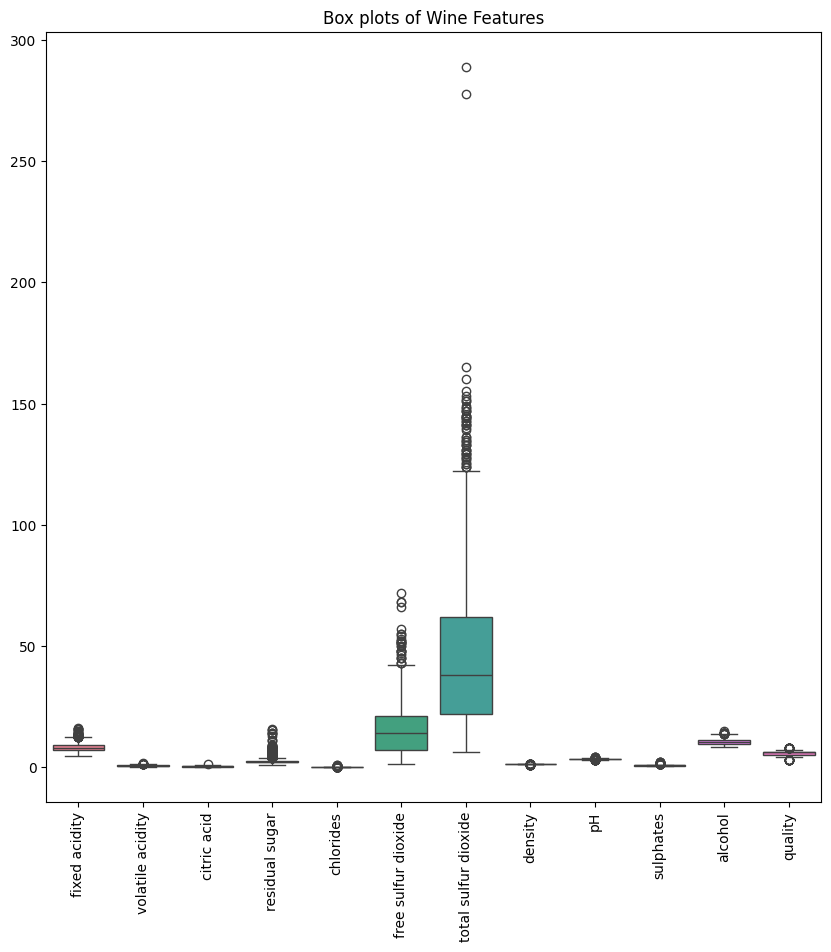

In [8]:
# Create figure and axes using plt.subplots()
# Select a numerical column 
# Plot boxplot to detect outliers visually
# Add title and axis labels
# Display the visualization

plt.figure(figsize = (10,10))
sns.boxplot(
    data = wine_df
)
plt.title("Box plots of Wine Features")
plt.xticks(rotation = 90)
plt.show()

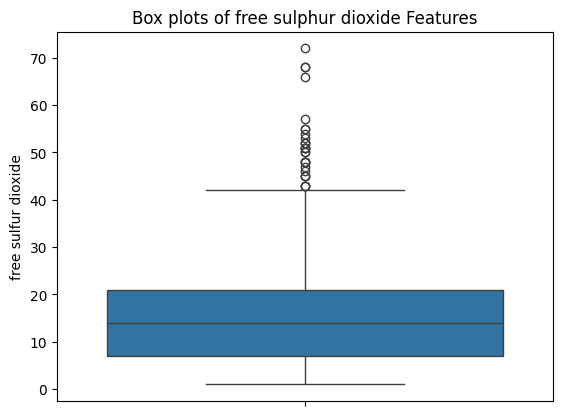

In [12]:
fig, ax = plt.subplots()
sns.boxplot(
    data = wine_df,
    y="free sulfur dioxide",
    ax = ax
)
plt.title("Box plots of free sulphur dioxide Features")
plt.xticks(rotation = 90)
plt.show()

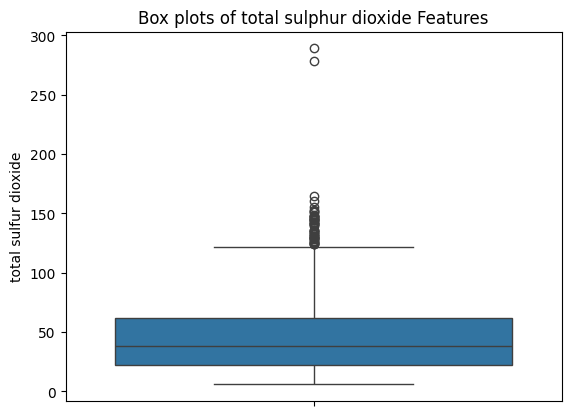

In [13]:
fig, ax = plt.subplots()
sns.boxplot(
    data = wine_df,
    y="total sulfur dioxide",
    ax = ax
)
plt.title("Box plots of total sulphur dioxide Features")
plt.xticks(rotation = 90)
plt.show()

# IQR Method (Interquartile Range)

IQR = Q3 - Q1

Where:
- Q1 = 25th percentile
- Q3 = 75th percentile

Outlier boundaries:
Lower Bound = Q1 - 1.5 × IQR  
Upper Bound = Q3 + 1.5 × IQR

Any value outside these bounds is considered an outlier.

In [14]:
# Calculate Q1 (25th percentile)
# Calculate Q3 (75th percentile)
# Compute IQR
# Define lower and upper bounds using IQR formula

Q1_free_sulphur_dioxide = wine_df["free sulfur dioxide"].quantile(0.25)
Q3_free_sulphur_dioxide = wine_df["free sulfur dioxide"].quantile(0.75)


IQR_free_sulphur_dioxide = Q3_free_sulphur_dioxide - Q1_free_sulphur_dioxide

print("Q1 : ", Q1_free_sulphur_dioxide)
print("Q3 : ", Q3_free_sulphur_dioxide)
print("IQR : ", IQR_free_sulphur_dioxide)

Q1 :  7.0
Q3 :  21.0
IQR :  14.0


# 6. Detecting Outliers Using IQR Condition

After calculating lower and upper bounds,
we filter values that fall outside this range.

In [15]:
# Identify rows where numerical column is below lower bound
# Identify rows where numerical column is above upper bound
# Combine conditions to detect outliers
# Display detected outlier rows

lower_bound = Q1_free_sulphur_dioxide - 1.5 * IQR_free_sulphur_dioxide
upper_bound = Q3_free_sulphur_dioxide + 1.5 * IQR_free_sulphur_dioxide

print("Lower Bound: ", lower_bound)
print("Upper Bound: ", upper_bound)


Lower Bound:  -14.0
Upper Bound:  42.0


In [16]:
outliers_rows = wine_df[
    (wine_df['free sulfur dioxide']  < lower_bound )
    | 
    (wine_df['free sulfur dioxide'] > upper_bound)
]

In [17]:
outliers_rows

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
14,8.9,0.620,0.18,3.80,0.176,52.0,145.0,0.99860,3.16,0.88,9.2,5
15,8.9,0.620,0.19,3.90,0.170,51.0,148.0,0.99860,3.17,0.93,9.2,5
57,7.5,0.630,0.12,5.10,0.111,50.0,110.0,0.99830,3.26,0.77,9.4,5
396,6.6,0.735,0.02,7.90,0.122,68.0,124.0,0.99940,3.47,0.53,9.9,5
400,6.6,0.735,0.02,7.90,0.122,68.0,124.0,0.99940,3.47,0.53,9.9,5
497,7.2,0.340,0.32,2.50,0.090,43.0,113.0,0.99660,3.32,0.79,11.1,5
522,8.2,0.390,0.49,2.30,0.099,47.0,133.0,0.99790,3.38,0.99,9.8,5
584,11.8,0.330,0.49,3.40,0.093,54.0,80.0,1.00020,3.30,0.76,10.7,7
634,7.9,0.350,0.21,1.90,0.073,46.0,102.0,0.99640,3.27,0.58,9.5,5
678,8.3,0.780,0.10,2.60,0.081,45.0,87.0,0.99830,3.48,0.53,10.0,5


In [19]:
outliers_rows.shape
    

(30, 12)

# Strategies for Handling Outliers 

Outliers are data points that lie far outside the overall distribution of the dataset.  
They can significantly impact statistical analysis, visualization, and machine learning model performance.

Instead of always removing outliers, data scientists use multiple strategies based on:
- Domain knowledge
- Data quality
- Model sensitivity
- Business context

There is no single universal method — the correct approach depends on the dataset and problem.

## Removing Outliers (Direct Removal Method)

### Concept

The simplest strategy is to remove outliers from the dataset after detecting them using methods like:
- IQR Method
- Z-Score
- Boxplot analysis

This method reduces noise and improves model stability, especially for algorithms sensitive to extreme values (e.g., Linear Regression, KNN).

### When to Remove Outliers

Remove outliers when:
- They are caused by data entry errors
- They are measurement mistakes
- They are unrealistic values
- They do not represent real-world behavior

However, caution is required because some outliers may contain valuable information.

In [ ]:
# Detect outliers using IQR boundaries
# Filter dataset to remove values outside lower and upper bounds
# Create a cleaned dataset without outliers
# Compare dataset shape before and after removal

## Imputation (Replacing Outliers with Statistical Values)

### Concept

Imputation involves replacing outlier values with a substitute value such as:
- Mean
- Median (most preferred for outliers)
- Mode (for categorical data)

This approach keeps the data point but reduces the impact of extreme values.

### Why Median is Preferred for Outliers

The median is a robust statistic because:
- It is less affected by extreme values
- It preserves the central tendency better than mean
- It maintains dataset size while reducing distortion

In [20]:
# Identify outlier positions in the numerical feature
# Calculate median of the feature
# Replace outlier values with the median value (imputation)
# Verify updated distribution after imputation

wine_df["free sulfur dioxide"].describe()

count    1599.000000
mean       15.874922
std        10.460157
min         1.000000
25%         7.000000
50%        14.000000
75%        21.000000
max        72.000000
Name: free sulfur dioxide, dtype: float64

In [23]:
df_imputed = wine_df.copy()

medaian_free_sulphur_dioxide = df_imputed["free sulfur dioxide"].median()

df_imputed.loc[
    (df_imputed["free sulfur dioxide"] < lower_bound)
    |
    (df_imputed["free sulfur dioxide"] > upper_bound),
    "free sulfur dioxide"
] = medaian_free_sulphur_dioxide


In [24]:
df_imputed["free sulfur dioxide"].describe()

count    1599.000000
mean       15.163852
std         9.140986
min         1.000000
25%         7.000000
50%        14.000000
75%        21.000000
max        42.000000
Name: free sulfur dioxide, dtype: float64

## Winsorization (Capping Extreme Values)

### Concept

Winsorization is a technique where extreme outliers are not removed but capped at a specific percentile range.

Example:
- Values below 5th percentile → replaced with 5th percentile
- Values above 95th percentile → replaced with 95th percentile

This reduces the influence of extreme values while preserving dataset size.

### Advantages of Winsorization

- Keeps all observations in the dataset
- Reduces extreme variance
- Improves model stability
- Useful in financial and economic data

In [25]:
# Calculate lower percentile (e.g., 5th percentile)
# Calculate upper percentile (e.g., 95th percentile)
# Cap values below lower percentile
# Cap values above upper percentile
# Compare distribution before and after 

df_winsor = wine_df.copy()

# Calculate 5th and 95th percentiles
lower_cap = df_winsor["free sulfur dioxide"].quantile(0.05)
upper_cap = df_winsor["free sulfur dioxide"].quantile(0.95)

# Apply capping
df_winsor["free sulfur dioxide"] = np.where(
    df_winsor["free sulfur dioxide"] < lower_cap,
    lower_cap,
    np.where(df_winsor["free sulfur dioxide"] > upper_cap, upper_cap, df_winsor["free sulfur dioxide"])
)

# Check updated statistics
df_winsor["free sulfur dioxide"].describe()

count    1599.000000
mean       15.490619
std         9.234714
min         4.000000
25%         7.000000
50%        14.000000
75%        21.000000
max        35.000000
Name: free sulfur dioxide, dtype: float64

In [26]:
mean_val = wine_df["free sulfur dioxide"].mean()
median_val = wine_df["free sulfur dioxide"].median()

print("Mean (Affected by Outliers):", mean_val)
print("Median (Robust to Outliers):", median_val)

Mean (Affected by Outliers): 15.874921826141339
Median (Robust to Outliers): 14.0


# 9. Understanding Skewness

Skewness measures asymmetry in data distribution.

Types:
- Positive Skew (Right Skew) → Long right tail
- Negative Skew (Left Skew) → Long left tail
- Normal Distribution → Symmetrical

Skewed data affects:
- Mean-based models
- Linear regression
- Distance-based algorithms

In [40]:
# Calculate skewness of numerical features
# Identify which features are positively skewed
# Interpret skewness values

wine_df.skew().sort_values(ascending= False)

chlorides                  5.680347
residual sugar             4.540655
residual_sugar_sqrt        2.956763
sulphates                  2.428672
residual_sugar_log         1.806864
total sulfur dioxide       1.515531
free sulfur dioxide        1.250567
residual_sugar_log_sqrt    0.991876
fixed acidity              0.982751
alcohol                    0.860829
volatile acidity           0.671593
citric acid                0.318337
quality                    0.217802
pH                         0.193683
density                    0.071288
dtype: float64

## 📊 Interpretation of Skewness of Numerical Features

Skewness measures the asymmetry of a feature’s distribution:
- Skewness ≈ 0 → Approximately normal distribution  
- Skewness > 0 → Positively skewed (right tail)  
- Skewness < 0 → Negatively skewed (left tail)  

### 🔴 Highly Positively Skewed Features (Strong Right Skew)
- **chlorides (5.68)**
- **residual sugar (4.54)**
- **sulphates (2.43)**  
  - These features have extreme right skewness.
  - Most values are concentrated at lower ranges.
  - A few very large values (outliers) are stretching the tail to the right.
  - Log transformation or outlier handling may be required.

### 🟠 Moderately Positively Skewed Features
- **total sulfur dioxide (1.51)**
- **free sulfur dioxide (1.25)**
- **fixed acidity (0.98)**
- **alcohol (0.86)**
- **volatile acidity (0.67)**  
  - These features show noticeable right skew.
  - Indicates presence of higher-value outliers.
  - May benefit from scaling or mild transformation.

### 🟢 Slightly Skewed / Near-Normal Features
- **citric acid (0.32)**
- **quality (0.22)**
- **pH (0.19)**
- **density (0.07)**  
  - These features are close to symmetric.
  - Distribution is approximately normal.
  - Minimal preprocessing is needed.

### 🧠 Overall Insight
- Most numerical features are **positively skewed**, especially chemical-related variables.
- High skewness suggests the presence of **outliers and non-normal distributions**.
- Models sensitive to distribution (e.g., Linear Regression, KNN) may require:
  - Log transformation  
  - Robust scaling  
  - Outlier treatment  
- Tree-based models (e.g., Random Forest, XGBoost) are generally less affected by skewness.

# 10. Visualizing Skewed Distribution

Before applying transformation, we must visualize the skewed feature.

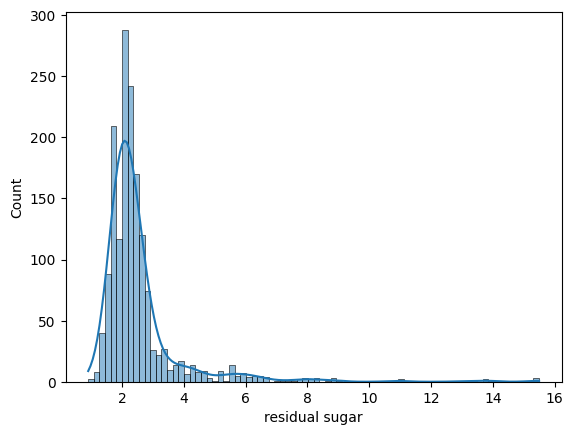

In [37]:
# Create histogram for a skewed feature 
# Add KDE curve for smooth visualization
# Add title and labels
# Show plot

fig, ax = plt.subplots()
sns.histplot(
    data=wine_df,
    x="residual sugar",
    kde = True,
    ax =ax
)
plt.show()

# 11. Log Transformation (Handling Positive Skew)

Log transformation reduces right skewness.

It compresses large values and makes distribution more symmetrical.

Note:
Log transformation works only on positive values.

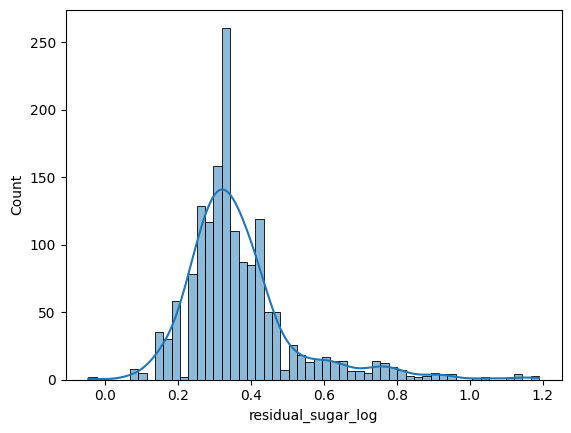

In [38]:
# Apply log transformation to skewed feature
# Create a new transformed column
# Plot histogram of transformed feature
# Compare distribution before and after transformation

wine_df["residual_sugar_log"] = np.log10(wine_df["residual sugar"])

fig, ax = plt.subplots()
sns.histplot(
    data=wine_df,
    x="residual_sugar_log",
    kde = True,
    ax =ax
)
plt.show()



In [ ]:
# wine_df["residual_sugar_log"] = np.log10(wine_df["residual sugar"])

# fig, ax = plt.subplots()
# sns.histplot(
#     data=wine_df,
#     x="residual_sugar_log",
#     kde = True,
#     ax =ax
# )
# plt.show()

# 12. Square Root Transformation

Square root transformation is milder than log transformation.
Used when skewness is moderate.

/home/fm-pc-lt-269/anaconda3/envs/datascience/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


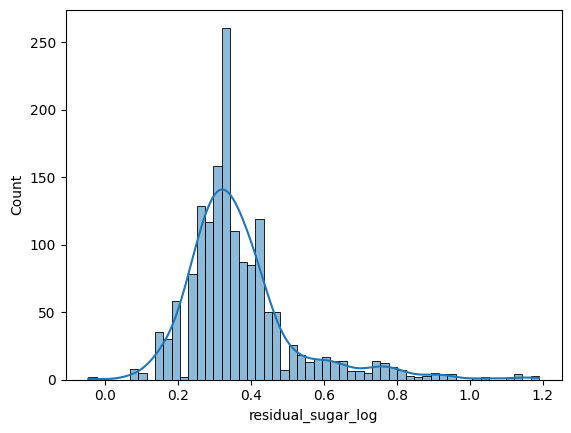

In [39]:
# Apply square root transformation to skewed feature
# Create new column for sqrt-transformed data
# Plot histogram of transformed feature
# Compare with original distribution

wine_df["residual_sugar_log_sqrt"] = np.sqrt(wine_df["residual_sugar_log"])

fig, ax = plt.subplots()
sns.histplot(
    data=wine_df,
    x="residual_sugar_log",
    kde = True,
    ax =ax
)
plt.show()


In [ ]:
wine_df["residual_sugar_sqrt"] = np.sqrt(wine_df["residual sugar"])

fig, ax = plt.subplots()
sns.histplot(
    data=wine_df,
    x="residual_sugar_sqrt",
    kde = True,
    ax =ax
)
plt.show()


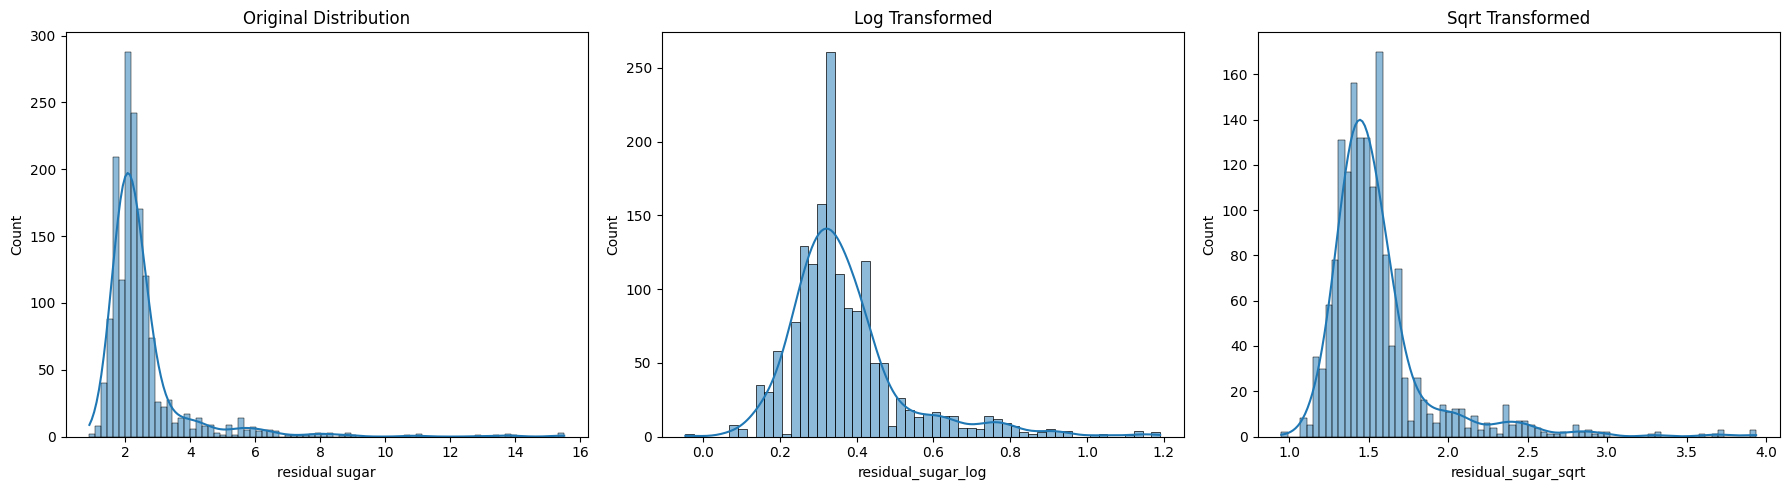

In [41]:
# Final distribution comparison (before vs after)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(wine_df["residual sugar"], kde=True, ax=axes[0])
axes[0].set_title("Original Distribution")

sns.histplot(wine_df["residual_sugar_log"], kde=True, ax=axes[1])
axes[1].set_title("Log Transformed")

sns.histplot(wine_df["residual_sugar_sqrt"], kde=True, ax=axes[2])
axes[2].set_title("Sqrt Transformed")

plt.tight_layout()
plt.show()

# 13. Box-Cox Transformation 

Box-Cox transformation is an advanced method
used to normalize skewed data.

It automatically finds the best power transformation.

Note:
Works only on positive data.

In [42]:
from scipy.stats import boxcox

In [43]:
# Import necessary module for Box-Cox transformation
# Apply Box-Cox transformation on positive skewed feature
# Plot transformed distribution
# Compare skewness before and after

wine_df["residual sugar"].min()



np.float64(0.9)

In [44]:
wine_df['residual sugar_boxcox'], lambda_value = boxcox(wine_df['residual sugar'])

print("Optimal Lambda For BOX COX", lambda_value)

Optimal Lambda For BOX COX -1.180347643587368


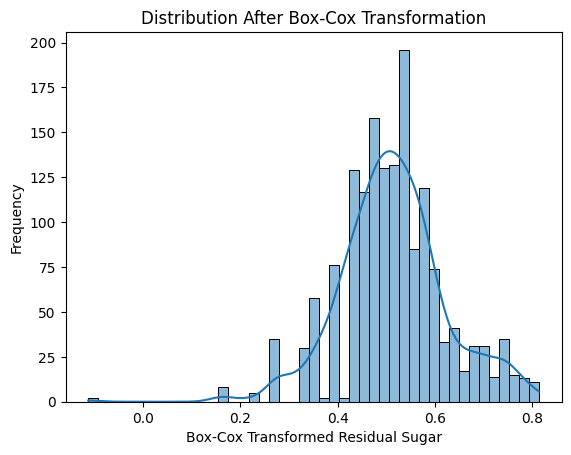

In [47]:
fig, ax = plt.subplots()
sns.histplot(data=wine_df, x="residual sugar_boxcox", kde=True, ax=ax)

ax.set_title("Distribution After Box-Cox Transformation")
ax.set_xlabel("Box-Cox Transformed Residual Sugar")
ax.set_ylabel("Frequency")

plt.show()

In [49]:
print("Original Skewness:", wine_df["residual sugar"].skew())
print("Log Transformed Skewness:", wine_df["residual_sugar_log"].skew())
print("Sqrt Transformed Skewness:", wine_df["residual_sugar_sqrt"].skew())
print("Box-Cox Transformed Skewness:", wine_df["residual sugar_boxcox"].skew())

Original Skewness: 4.54065542590319
Log Transformed Skewness: 1.8068638195807194
Sqrt Transformed Skewness: 2.9567627473692695
Box-Cox Transformed Skewness: -0.09593006500911178


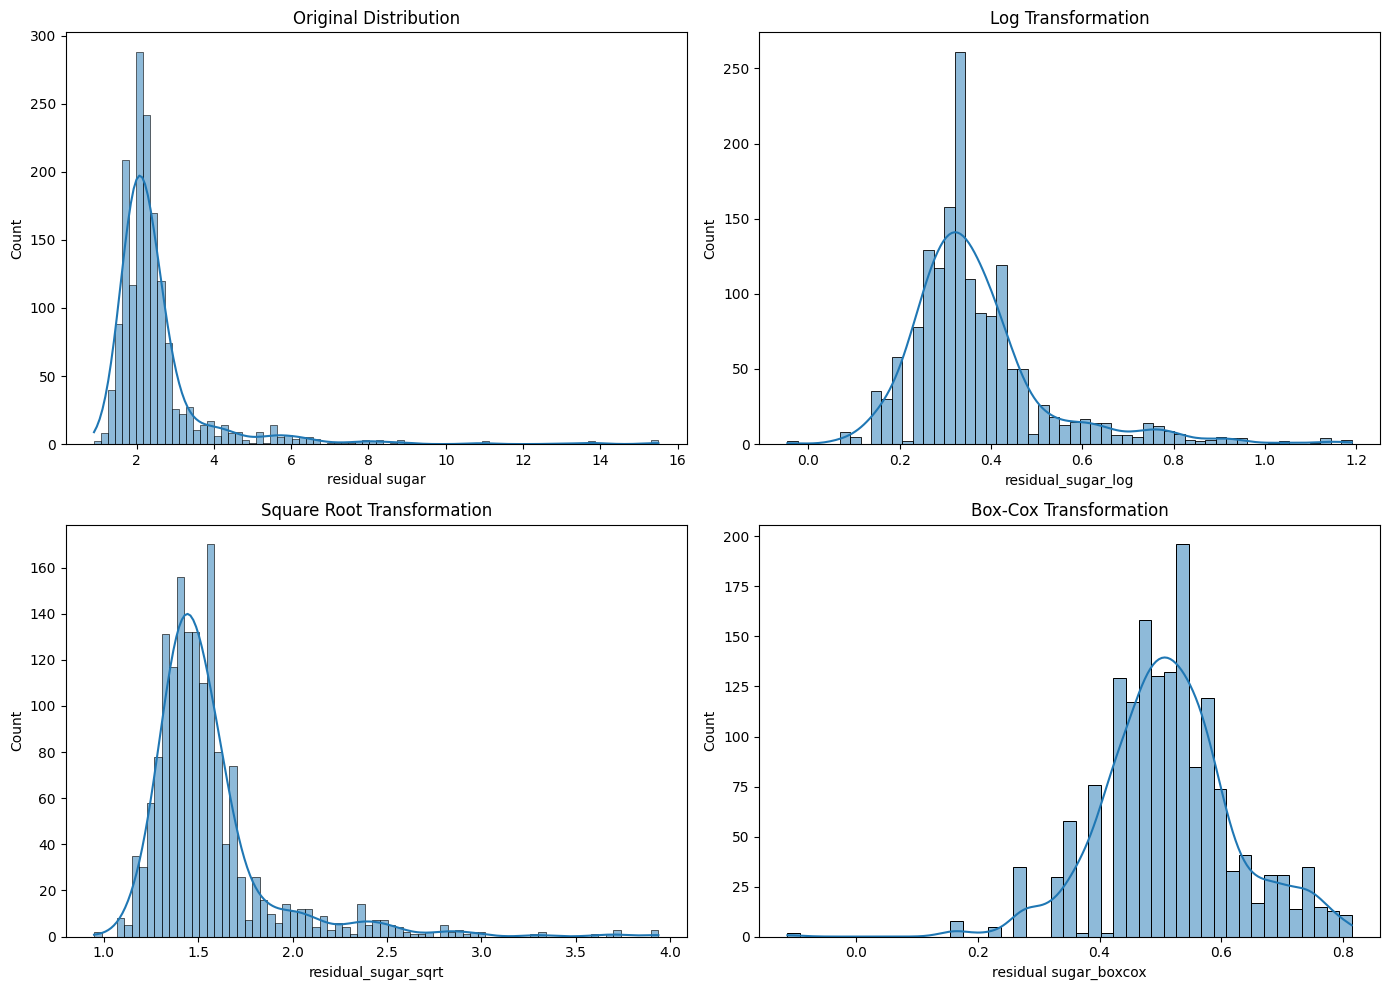

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original
sns.histplot(wine_df["residual sugar"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Original Distribution")

# Log Transform
sns.histplot(wine_df["residual_sugar_log"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Log Transformation")

# Sqrt Transform
sns.histplot(wine_df["residual_sugar_sqrt"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Square Root Transformation")

# Box-Cox Transform
sns.histplot(wine_df["residual sugar_boxcox"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Box-Cox Transformation")

plt.tight_layout()
plt.show()

In [54]:
# Create a negatively skewed distribution (left-skewed)
np.random.seed(42)
neg_skew_data = np.random.beta(a=5, b=2, size=1000) * 10  # Left-skewed

# Convert to pandas Series for easier handling
neg_skew_series = pd.Series(neg_skew_data, name="neg_skew_feature")

# Check skewness
print("Skewness (Negative Skew Data):", neg_skew_series.skew())

Skewness (Negative Skew Data): -0.5126228141137633


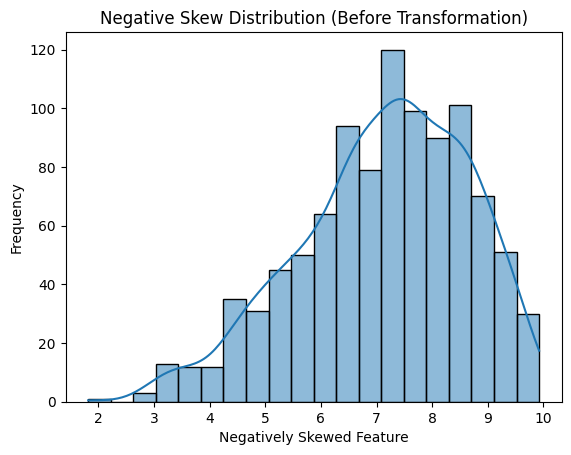

In [55]:
# Plot histogram + KDE of negatively skewed data
fig, ax = plt.subplots()
sns.histplot(neg_skew_series, kde=True, ax=ax)

ax.set_title("Negative Skew Distribution (Before Transformation)")
ax.set_xlabel("Negatively Skewed Feature")
ax.set_ylabel("Frequency")

plt.show()

In [56]:
# Reflect the data (max + 1 - x) to handle negative skew
reflected_data = neg_skew_series.max() + 1 - neg_skew_series

# Check skewness after reflection
print("Skewness After Reflection:", reflected_data.skew())

Skewness After Reflection: 0.5126228141137634


In [57]:
# Apply log transformation on reflected data
log_transformed_neg = np.log1p(reflected_data)

# Check skewness after log transformation
print("Skewness After Reflection + Log:", log_transformed_neg.skew())

Skewness After Reflection + Log: -0.1731805720198178


In [58]:
# Apply square transformation
square_transformed_neg = np.power(neg_skew_series, 2)

# Check skewness after square transformation
print("Skewness After Square Transformation:", square_transformed_neg.skew())

Skewness After Square Transformation: -0.03065826595682718


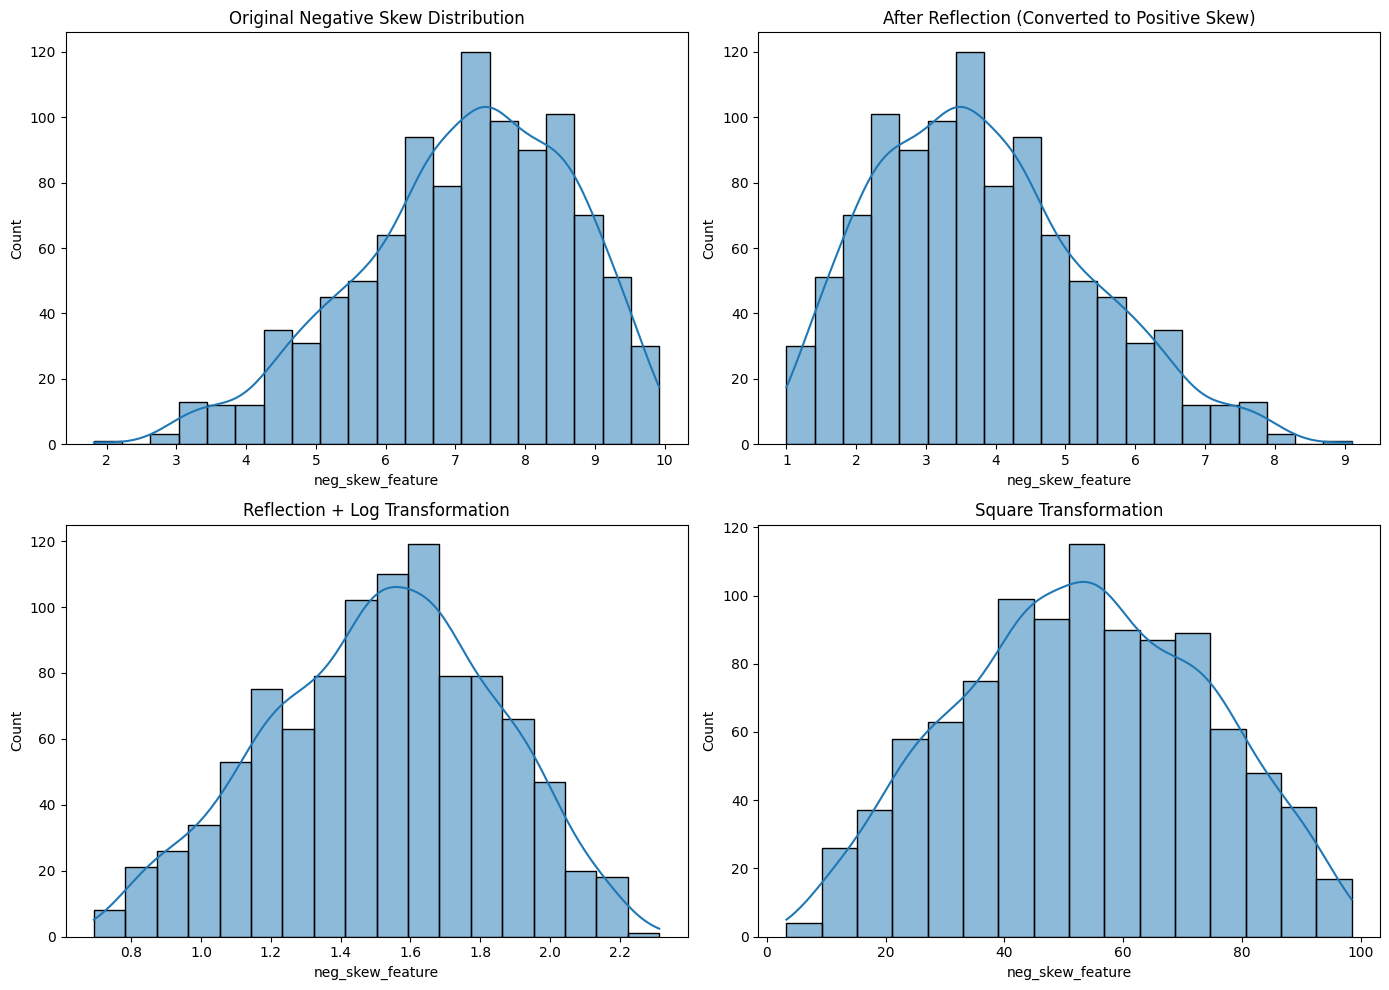

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original Negative Skew
sns.histplot(neg_skew_series, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Original Negative Skew Distribution")

# Reflected Distribution
sns.histplot(reflected_data, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("After Reflection (Converted to Positive Skew)")

# Reflection + Log Transform
sns.histplot(log_transformed_neg, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Reflection + Log Transformation")

# Square Transformation
sns.histplot(square_transformed_neg, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Square Transformation")

plt.tight_layout()
plt.show()